# DR-EarlyXAI: RETFound Inference & Transformer Grad-CAM
Interactive notebook for DR severity prediction and Transformer Grad-CAM on retinal fundus images using **RETFound**.

In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Add project root and RETFound to sys.path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "RETFound"))
sys.path.insert(0, str(PROJECT_ROOT))

import models_vit as models
from xai.gradcam import RETFoundGradCAM, load_model_input, load_visualization_image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\vuppa\Desktop\DR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# Reconstruct RETFound_mae and load weights
model = models.RETFound_mae(
    img_size=224,
    num_classes=5,
    drop_path_rate=0.2,
    global_pool=True,
)

checkpoint_path = PROJECT_ROOT / "checkpoint-best.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
state_dict = checkpoint["model"]
clean_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

missing, unexpected = model.load_state_dict(clean_state_dict, strict=False)
print(f"Loaded checkpoint! Missing keys: {len(missing)}, Unexpected: {len(unexpected)}")
model = model.to(DEVICE)
model.eval()

Loaded checkpoint! Missing keys: 0, Unexpected: 0


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Id

In [3]:
# Initialize Grad-CAM targeting final block LayerNorm
TARGET_LAYER = model.blocks[-1].norm1
gradcam = RETFoundGradCAM(model=model, target_layer=TARGET_LAYER, device=DEVICE)
print("Grad-CAM ready.")

Grad-CAM ready.


Image: 0005cfc8afb6.png
Prediction: Grade 2 (Moderate) (69.40% confidence)
  [0] Grade 0 (No DR)            :  0.36%
  [1] Grade 1 (Mild)             : 22.90%
  [2] Grade 2 (Moderate)         : 69.40%
  [3] Grade 3 (Severe)           :  3.54%
  [4] Grade 4 (Proliferative DR) :  3.79%


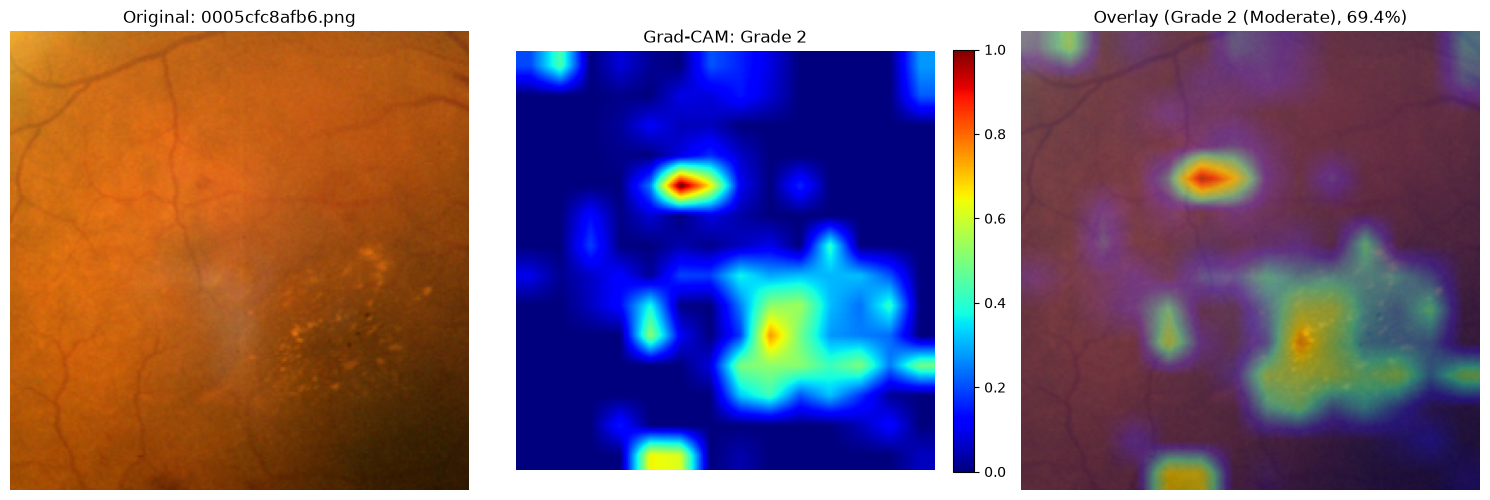

In [4]:
CLASS_NAMES = ["Grade 0 (No DR)", "Grade 1 (Mild)", "Grade 2 (Moderate)", "Grade 3 (Severe)", "Grade 4 (Proliferative DR)"]

# Pick any test image
test_images = list((PROJECT_ROOT / "test_images").glob("*.png"))
sample_idx = 0  # Change index to test other images!
image_path = test_images[sample_idx]
print("Image:", image_path.name)

# Run Grad-CAM
input_tensor = load_model_input(image_path, DEVICE)
result = gradcam.generate(input_tensor)

pred = result["predicted_class"]
conf = result["confidence"]
cam = result["cam"]
original = load_visualization_image(image_path)

print(f"Prediction: {CLASS_NAMES[pred]} ({conf*100:.2f}% confidence)")
for grade, p in enumerate(result["probabilities"]):
    print(f"  [{grade}] {CLASS_NAMES[grade]:<27}: {p*100:5.2f}%")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original); axes[0].set_title(f"Original: {image_path.name}"); axes[0].axis("off")
im_cam = axes[1].imshow(cam, cmap="jet", vmin=0, vmax=1); axes[1].set_title(f"Grad-CAM: Grade {pred}"); axes[1].axis("off")
fig.colorbar(im_cam, ax=axes[1], fraction=0.046, pad=0.04)
axes[2].imshow(original); axes[2].imshow(cam, cmap="jet", alpha=0.45, vmin=0, vmax=1)
axes[2].set_title(f"Overlay ({CLASS_NAMES[pred]}, {conf*100:.1f}%)"); axes[2].axis("off")
plt.tight_layout()
plt.show()